# Von der STAC-Suche bis zur Erstellung von Composites

## Passende Szenen via STAC suchen

### Parameter definieren

Achtung bei der Definition der untersuchten Jahre: range() exkludiert die letzte Zahl --> daher +1

In [1]:
# Link zum STAC-Catalog --> belassen!
catalog_link = "https://planetarycomputer.microsoft.com/api/stac/v1"

# Plattform spefizieren
platform = "sentinel-2-l2a"

# Start- und Enddatum definieren
years = range(2021, 2025+1) # hier die zu betrachtenden Jahre (Start- und Endjahr) spezifizieren
range_start_date = "-06-01" # hier den jeweiligen Zeitraum (z.B. 1. Juni - 31. Juli) spezifizieren
range_end_date = "-07-31"

# Cloud Cover (max) definieren --> pro Tile nicht pro Szene
cloud = 40 # etwas locker lassen, Auswahl der am wenigsten bewölkten Szene ÜBER AOI folgt später

# benötigte Bänder spezifizieren (so wie sie heissen!!)
bands = ["B02", "B03", "B04", "B08", "B12"]  # Blue, Green, Red, NIR, SWIR
scl = ["SCL"]                                # SCL für Wolkenmaskierung

### Polygon der AOI laden

Vorbereitetes Polygon importieren, erstellt in **`1_AOI_Polygon_vorbereiten`**

In [2]:
import geopandas as gpd

# Polygon AOI einlesen & in CRS "WGS 84" bringen
aoi = gpd.read_file("polygon_aoi.geojson").to_crs("EPSG:4326") # WGS84 -> wichtig für STAC-Suche

# Geometrie des Polygons ableiten für die STAC-Suche
aoi_geom = aoi.geometry.iloc[0]

In [3]:
# kurz Visualisieren zur Überprüfung

import folium

centroid = aoi_geom.centroid

m = folium.Map(location=[centroid.y, centroid.x], zoom_start=11)

folium.GeoJson(aoi_geom).add_to(m)

m

### Libraries importieren

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pystac_client 

import stackstac
from collections import defaultdict
from shapely.geometry import shape
from shapely.ops import unary_union

from pystac_client import Client 
import planetary_computer as pc
import rioxarray as rio
import xarray as xr

### Workflow 

Ziel: Für jeden untersuchten Zeitraum wird die beste verfügbare, vollständige Szene identifiziert, die die gesamte AOI abdeckt und den definierten Kriterien (Zeitraum, maximale Wolkenbedeckung etc.) entspricht.

1. Passende Tiles gemäss definierten Parametern suchen
   - Abfrage von Daten über den STAC-Katalog
   - Filterung nach:
       - Trägerplattform 
       - definiertem Zeitraum 
       - räumlichem Bezug zur AOI 
       - maximaler Wolkenbedeckung (pro Tile) 
   - **Ergebnis**: Liste von STAC-Items (Tiles), welche die Suchkriterien erfüllen
2. Gruppierung nach Aufnahmedatum
   - Gruppierung aller Tiles nach ihrem Aufnahmedatum
   - Tiles mit gleichem Datum gehören zur gleichen Szene
   - **Ergebnis**: Jede Datumsgruppe entspricht einer potenziellen Szene (bestehend aus einem oder mehreren Tiles)
3. Szenenbewertung und -filterung
   - 3.1 Duplikate entfernen 
       - Pro Datumsgruppe Identifikation von Tiles mit identischer Geometrie
       - Beibehaltung eines repräsentativen Tiles pro Geometrie
   - 3.2 Sicherstellen, dass die ganze AOI abgedeckt wird
       - Umwandlung der Tile-Geometrien in Polygone
       - Bildung der geometrischen Vereinigung (union) aller Tiles pro Szene
       - Berechnung der Schnittfläche (intersection) mit der AOI
       - Bestimmung des Abdeckungsgrades
    - 3.3 Valide Szenen auswählen 
       - Nur Szenen mit ausreichender Abdeckung (z. B. ≥ 99 %) werden berücksichtigt
   - **Ergebnis**: Liste gültiger Szenen, welche AOI ausreichend abdecken & keine geometrischen Duplikate enthalten
4. Ausgabe der validierten Szenen pro Zeitraum
   - **Ergebnis**: Liste mit validen Szenen pro zu untersuchendem Zeitraum

**Gesamtergebnis: vollständige Szenen (aus einem oder mehreren Tiles), die als Grundlage für die weitere Rasteranalyse dienen.**

### Aufbau STAC-Suche

Siehe auch [Reading Data from the STAC API](https://github.com/microsoft/PlanetaryComputerExamples/blob/main/quickstarts/reading-stac.ipynb) und dieses [YouTube Video](https://www.youtube.com/watch?v=HHCsFHCQW5g)

**Die Funktionen werden jeweils mit einem Testjahr überprüft.**

In [5]:
year_test = 2022

In [6]:
## kleiner Überblick über die Sentinel-2-Level-2a Kollektion

cat = Client.open(catalog_link)
sentinel_collection = cat.get_collection(platform) # platform = "sentinel-2-l2a"

pd.DataFrame.from_dict(sentinel_collection.to_dict()["item_assets"], orient = "index")

,gsd,type,roles,title,eo:bands
AOT,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Aerosol optical thickness (AOT),NaN
B01,60.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 1 - Coastal aerosol - 60m,"[{'name': 'B01', 'common_name': 'coastal', 'de..."
B02,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 2 - Blue - 10m,"[{'name': 'B02', 'common_name': 'blue', 'descr..."
B03,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 3 - Green - 10m,"[{'name': 'B03', 'common_name': 'green', 'desc..."
B04,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 4 - Red - 10m,"[{'name': 'B04', 'common_name': 'red', 'descri..."
B05,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 5 - Vegetation red edge 1 - 20m,"[{'name': 'B05', 'common_name': 'rededge', 'de..."
B06,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 6 - Vegetation red edge 2 - 20m,"[{'name': 'B06', 'common_name': 'rededge', 'de..."
B07,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 7 - Vegetation red edge 3 - 20m,"[{'name': 'B07', 'common_name': 'rededge', 'de..."
B08,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 8 - NIR - 10m,"[{'name': 'B08', 'common_name': 'nir', 'descri..."
B09,60.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 9 - Water vapor - 60m,"[{'name': 'B09', 'description': 'Band 9 - Wate..."


#### 0. STAC-Katalog öffnen

In [7]:
catalog = Client.open(
    catalog_link, 
    modifier=pc.sign_inplace,  # damit werden die Resultate automatisch "signed" --> Zugriff
) 

#### 1. Passende Tiles suchen

Beschreibung der Funktion **`search_items`**:

In der Funktion `search_items` wird für ein gegebenes Jahr (`year`) im geöffneten STAC-Katalog (`catalog`) nach geeigneten Tiles gesucht. Zunächst wird auf Basis des übergebenen Jahres ein konkreter Suchzeitraum definiert und anschliessend eine STAC-Abfrage gemäss definierter Kriterien (Plattform, AOI etc.) durchgeführt. 

Die Suchergebnisse werden als Liste von STAC-Items (`items`) gespeichert. Jedes Item entspricht dabei einem einzelnen Tile inklusive zugehöriger Metadaten. 
Zur Kontrolle wird die Anzahl der gefundenen Tiles pro Jahr ausgegeben. Falls keine passenden Tiles gefunden werden, erfolgt eine entsprechende Hinweismeldung.

Die Funktion gibt schliesslich die Liste der gefundenen STAC-Items (`items`) zurück, welche als Grundlage für die weitere Verarbeitung dient.

In [8]:
def search_items(catalog, year):

    # Zeitraum definieren:
    start_date = f"{year}{range_start_date}"
    end_date = f"{year}{range_end_date}"

    # STAC-Abfrage
    search = catalog.search(
        collections = [platform],
        intersects = aoi_geom,                         # Tiles müssen meine AOI schneiden
        datetime = f"{start_date}/{end_date}",
        query = {"eo:cloud_cover": {"lt": cloud}},
    )

    items = list(search.items())

    # Ausgabetext definieren, wie viele Tiles im entsprechenden Zeitraum gefunden wurden

    if len(items) == 0:
        print(f"Step 1 | search items: ❌ no data, adjust defined parameters")
    else:
        print(f"Step 1 | search items: {len(items)} tiles found")
        
    return items

In [9]:
# überprüfen mit Testjahr
items_test = search_items(catalog, year_test)
items_test[:4]

Step 1 | search items: 47 tiles found


[<Item id=S2A_MSIL2A_20220729T090601_R050_T34TGR_20220730T133614>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20220728T185023>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>]

#### 2. Gruppierung nach Datum

Beschreibung der Funktion **`group_by_date`**:

Die Funktion `group_by_date` dient dazu, eine Liste von STAC-Items (Tiles) nach ihrem Aufnahmedatum zu strukturieren. Zunächst wird ein leeres Dictionary (`items_by_date`) vom Typ *defaultdict(list)* erstellt, welches automatisch für jedes neue Datum eine leere Liste anlegt.

Anschliessend wird über alle übergebenen STAC-Items (`item`) iteriert. Für jedes Item wird der Aufnahmezeitpunkt (*item.datetime*) extrahiert und in ein standardisiertes Datumsformat umgewandelt. Dabei wird der Zeitanteil entfernt, sodass nur das reine Datum (YYYY-MM-DD) erhalten bleibt. Die einzelnen Items werden anschliessend anhand dieses Datums gruppiert, indem sie der entsprechenden Liste im Dictionary zugeordnet werden. Das Ergebnis ist eine strukturierte Sammlung, in der alle Tiles mit gleichem Aufnahmedatum zusammengefasst sind und somit potenzielle Szenen bilden.

Die Funktion gibt das Dictionary `items_by_date` zurück, welches die Grundlage für die anschliessende Szenenbildung und Filterung darstellt.

In [10]:
def group_by_date(items):
    items_by_date = defaultdict(list)

    # Für jedes STAC-Item (Tile) Aufnahmedatum extrahieren & Items anschliessend nach Datum gruppieren
    for item in items:

        # item.datetime enthält den Aufnahmezeitpunkt als Timestamp (z.B. "2022-06-15T10:32:00Z")
        # pd.to_datetime konvertiert diesen String in ein pandas datetime-Objekt
        # .date() entfernt die Zeitkomponente, sodass nur das reine Datum (YYYY-MM-DD) übrig bleibt
        
        date = pd.to_datetime(item.datetime).date()

        # items_by_date ist ein defaultdict(list) --> für jedes neue Datum wird automatisch eine leere Liste erstellt
        # Anschließend wird das aktuelle Item dieser Liste hinzugefügt.
        # Ergebnis: alle Satelliten-Tiles werden nach Aufnahmedatum gruppiert
        
        items_by_date[date].append(item)

    # Ausgabetext / Debug-Info definieren

    print(f"Step 2 | grouping by date: {len(items_by_date)} unique acquisition dates found")

    return items_by_date

In [11]:
# überprüfen mit Testjahr
items_by_date_test = group_by_date(items_test)
for date in items_by_date_test:
    print(date)

Step 2 | grouping by date: 15 unique acquisition dates found
2022-07-29
2022-07-27
2022-07-22
2022-07-19
2022-07-17
2022-07-14
2022-07-07
2022-07-02
2022-06-29
2022-06-27
2022-06-24
2022-06-19
2022-06-14
2022-06-07
2022-06-02


#### 3. Szenenbewertung und -filterung

**3.1 Duplikate entfernen**

STAC liefert teilweise mehrere Items mit identischer räumlicher Ausdehnung (z. B. aufgrund unterschiedlicher Processing-Level oder redundanter Produktvarianten). Diese Funktion dient dazu, solche Duplikate innerhalb einer Szene zu entfernen, sodass pro geometrischer Ausdehnung nur ein repräsentatives Item erhalten bleibt.

Beschreibung der Funktion **`remove_duplicates`**:

In dieser Funktion wird über alle Items einer Datumsgruppe iteriert. Für jedes Item wird die geometrische Ausdehnung extrahiert und in eine eindeutige Zeichenkette (WKT-Format) umgewandelt. Diese geometrische Signatur dient als eindeutiger Identifikator.

Ein Set (*seen*) wird verwendet, um bereits vorkommende Geometrien zu speichern. Falls eine Geometrie bereits enthalten ist, wird das entsprechende Item übersprungen. Andernfalls wird die Geometrie zum Set hinzugefügt und das Item in die Liste der eindeutigen Elemente aufgenommen.

Das Ergebnis ist eine bereinigte Liste von STAC-Items (`unique_group`), in der jede räumliche Ausdehnung innerhalb einer Szene nur einmal vertreten ist. Die Variable `group` wird im Hauptloop beim Iterieren über das Dictionary `items_by_date` zugewiesen und repräsentiert jeweils die Liste der STAC-Items, die einem gemeinsamen Aufnahmedatum zugeordnet sind.

In [12]:
def remove_duplicates(group):
    seen = set()
    unique_group = []                              # Leere Liste für Output erstellen

    for item in group:
        geom_key = shape(item.geometry).wkt        # eindeutige geometrische Signatur

        if geom_key in seen:
            continue

        seen.add(geom_key)
        unique_group.append(item)

    return unique_group

In [13]:
# überprüfen mit Testjahr & Testgruppe

# Eine Datumgruppe vor Duplikatentfernung auswählen zum Vergleich
date_example = list(items_by_date_test.keys())[1]
group_example = items_by_date_test[date_example]
group_example

[<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20220728T185023>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20220728T192839>]

In [14]:
# Eine Datumgruppe nach Duplikatentfernung auswählen
clean_group = remove_duplicates(group_example)
clean_group

[<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>]

In [15]:
# --> geometrische Duplikate wurden entfernt (von 4 auf 2 Tiles)

**3.2 Abdeckung der AOI prüfen**

Hier wird geprüft, ob die Tiles (`item`) in den jeweiligen Datumsgruppen die gesamte AOI überdecken (keine Lücken).

Beschreibung der Funktion **`calculate_coverage`**:

In dieser Funktion wird die räumliche Abdeckung der AOI durch die zu einer Szene gehörenden STAC-Items berechnet. Als Eingabe dient die von Duplikaten bereinigte Liste `unique_group`, welche eine Liste von STAC-Items repräsentiert, die alle demselben Aufnahmedatum zugeordnet sind. Zusätzlich wird die AOI-Geometrie (`aoi_geom`) übergeben.

Zunächst wird für jedes Item (`item`) in der Gruppe (`unique_group`) die geometrische Ausdehnung extrahiert und in eine Liste von Shapely-Polygonen (`footprints`) umgewandelt. Anschliessend werden alle Polygone mittels geometrischer Vereinigung (*unary_union*) zu einer Gesamtgeometrie (`union`) zusammengeführt, welche die gesamte räumliche Abdeckung aller Tiles dieser Szene repräsentiert.

Zuletzt wird das Flächenverhältnis der Schnittmenge (`coverage`) zwischen der Gesamtgeometrie und der AOI berechnet. Das Ergebnis ist ein Wert zwischen 0 und 1, wobei 1 einer vollständigen Abdeckung der AOI entspricht.

In [16]:
def calculate_coverage(unique_group, aoi_geom):

    # Für jedes Item (Tile) in der Gruppe wird die Geometrie in ein Shapely-Polygon umgewandelt.
    # Ergebnis: Liste von Polygonen, die die räumliche Ausdehnung der einzelnen Tiles darstellen.
    footprints = [shape(item.geometry) for item in unique_group]

    # Vereint alle Tile-Polygone zu einer einzigen Gesamtfläche (Union).
    # Dadurch entsteht die gesamte von allen Tiles gemeinsam abgedeckte Fläche dieses Datums.
    union = unary_union(footprints)

    # Berechung der Abdeckung meiner AOI durch die Tiles 
    coverage = union.intersection(aoi_geom).area / aoi_geom.area

    return coverage

In [17]:
# überprüfen mit Testjahr 
coverage_by_date = {}

for date, group in items_by_date_test.items():
    
    # Duplikate entfernen
    unique_group = remove_duplicates(group)
    
    # Coverage berechnen
    coverage = calculate_coverage(unique_group, aoi_geom)
    
    coverage_by_date[date] = coverage

In [18]:
coverage_by_date

{datetime.date(2022, 7, 29): 0.05769072123107963,
 datetime.date(2022, 7, 27): 0.9999999999999987,
 datetime.date(2022, 7, 22): 0.9999999999999987,
 datetime.date(2022, 7, 19): 0.9999999999999987,
 datetime.date(2022, 7, 17): 0.9999999999999987,
 datetime.date(2022, 7, 14): 0.9999999999999987,
 datetime.date(2022, 7, 7): 0.05769075272615751,
 datetime.date(2022, 7, 2): 0.9999999999999987,
 datetime.date(2022, 6, 29): 0.9999999999999987,
 datetime.date(2022, 6, 27): 0.9999999999999987,
 datetime.date(2022, 6, 24): 0.9999999999999987,
 datetime.date(2022, 6, 19): 0.9999999999999987,
 datetime.date(2022, 6, 14): 0.05769076040138965,
 datetime.date(2022, 6, 7): 0.9999999999999987,
 datetime.date(2022, 6, 2): 0.9999999999999987}

**3.3 Valide Szenen speichern**

In diesem Schritt werden aus den nach Aufnahmedatum gruppierten und bereits bereinigten STAC-Items nur jene Szenen ausgewählt, welche eine nahezu vollständige räumliche Abdeckung der definierten Area of Interest (AOI) aufweisen.

Beschreibung der Funktion **`build_valid_scenes`**:

In dieser Funktion wird über alle im Dictionary `items_by_date` enthaltenen Datumsgruppen iteriert.

Für jede Datumsgruppe wird zunächst die Funktion `remove_duplicates` angewendet, um redundante geometrische Ausdehnungen innerhalb der Szene zu entfernen. Die daraus resultierende bereinigte Liste (`unique_group`) wird anschliessend an die Funktion `calculate_coverage` übergeben, um den räumlichen Abdeckungsgrad der AOI durch die jeweiligen Satelliten-Tiles zu bestimmen. Nur Szenen mit einer Abdeckung von mindestens 0.99 (99%) werden als vollständig betrachtet und in die Ergebnisliste aufgenommen.

Für jede gültige Szene wird ein Dictionary erstellt und der Liste `valid_scenes` hinzugefügt.

Die Funktion gibt abschliessend eine Liste aller gültigen Szenen zurück, welche sowohl räumlich konsistent als auch nahezu vollständig die definierte AOI abdecken und somit für weiterführende Analysen geeignet sind.

In [19]:
def build_valid_scenes(items_by_date, aoi_geom, year):

    valid_scenes = []

    for date, group in items_by_date.items():

        unique_group = remove_duplicates(group)
        coverage = calculate_coverage(unique_group, aoi_geom)

        if coverage < 0.99:
            continue

        valid_scenes.append({
            "year": year,
            "date": date,
            "items": unique_group,
            "coverage": coverage,
            "n_tiles": len(unique_group)
        })

    return valid_scenes

In [20]:
scenes_test = build_valid_scenes(items_by_date_test, aoi_geom, year_test)
scenes_test

[{'year': 2022,
  'date': datetime.date(2022, 7, 27),
  'items': [<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
   <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 19),
  'items': [<Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20220719T222812>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20220719T225317>],
  'coverage': 0.9999999999999987,
  'n_tiles': 4},
 {'year': 2022,
  'date': datetime.date(2022, 7, 17),
  'items': [<Item id=S2B_MSIL2A_20220717T091559_R

In [21]:
len(scenes_test)
# --> entspricht den 12 Datumsgruppen mit > 0.99 Abdeckung

12

#### 4. Validierte Szenen bestätigen und ausgeben

Beschreibung der Funktion **`get_valid_scenes`**:

In dieser Funktion wird die zuvor erzeugte Liste gültiger Szenen (`valid_scenes`) für ein gegebenes Jahr (`year`) geprüft und für die weitere Verarbeitung zurückgegeben.

Zunächst wird geprüft, ob überhaupt gültige Szenen vorhanden sind. Falls die Liste leer ist, bedeutet dies, dass für das betrachtete Jahr keine Szene existiert, welche die definierten Kriterien (insbesondere eine ausreichende AOI-Abdeckung) erfüllt. In diesem Fall wird eine entsprechende Meldung ausgegeben.

Sind gültige Szenen vorhanden, werden diese nicht weiter reduziert oder priorisiert, sondern vollständig beibehalten. Die Auswahl einer einzelnen „besten“ Szene erfolgt bewusst nicht in diesem Schritt, da die endgültige Bewertung (anhand von Wolkenbedeckung aus SCL-Daten) erst in einem späteren Verarbeitungsschritt stattfindet.

***Die Funktion dient somit primär der Validierung des Vorhandenseins geeigneter Szenen sowie der strukturierten Ausgabe der Zwischenergebnisse im Rahmen der Verarbeitungskette.***

Das Ergebnis der Funktion ist eine Liste von Dictionaries (`valid_scenes`), welche die zuvor validierten Szenen für das jeweilige Jahr enthält. Diese werden unverändert in die übergeordnete Ergebnisstruktur (`selected_scenes`) übernommen.

In [22]:
def get_valid_scenes(valid_scenes, year):

    # Prüfen, ob es für das aktuelle Jahr gültige Szenen gibt, ansonsten weiter zur nächsten Iteration in der Schleife (Jahr)
    if len(valid_scenes) == 0:
        
        # Ausgabetext, falls keine der Szenen (pro Jahr) die AOI abdeckt (99%)
        print(f"Step 3 | spatial coverage check: ❌ no scene with full AOI coverage")   
        
        return [] # Falls kein Ergebnis gefunden wurde, "nichts hinzufügen"

    # Ausgabetext für das Suchergebnis (Endresultat) definieren
    print(f"Step 3 | spatial coverage check: ✅ {len(valid_scenes)} valid scenes kept")

    print("-" * 63) # als Abgrenzung zur nächsten Iteration

    return valid_scenes

In [23]:
# überprüfen mit Testjahr
get_valid_scenes(scenes_test, year_test)

Step 3 | spatial coverage check: ✅ 12 valid scenes kept
---------------------------------------------------------------


[{'year': 2022,
  'date': datetime.date(2022, 7, 27),
  'items': [<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
   <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 19),
  'items': [<Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20220719T222812>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20220719T225317>],
  'coverage': 0.9999999999999987,
  'n_tiles': 4},
 {'year': 2022,
  'date': datetime.date(2022, 7, 17),
  'items': [<Item id=S2B_MSIL2A_20220717T091559_R

### Hauptloop über alle Untersuchungszeuträume

In [24]:
# Leere Liste erstellen, in der die final ausgewählten Szenen gespeichert werden
selected_scenes = []

# Schleife über alle definierten Jahre
for year in years:

    print(f"Year: {year}") # Ausgabetext zur besseren Abtrennung der Jahre

    # ---------------------------
    # 1. STAC-Suche durchführen
    # ---------------------------
    
    # Für das jeweilige Jahr werden alle passenden Sentinel-2 Tiles geladen
    items = search_items(catalog, year)

    # Falls keine Tiles gefunden wurden: aktuelles Jahr überspringen und mit nächster Iteration weitermachen
    if len(items) == 0:
        continue

    # ---------------------------
    # 2. Gruppierung nach Datum
    # ---------------------------
    
    # Alle gefundenen Tiles werden nach ihrem Aufnahmedatum gruppiert
    items_by_date = group_by_date(items)

    # ---------------------------
    # 3. Szenen filtern (ausgelagert)
    # ---------------------------

    valid_scenes = build_valid_scenes(items_by_date, aoi_geom, year)

    # ---------------------------
    # 4. Verbleibende Szenen auswählen
    # ---------------------------

    scenes = get_valid_scenes(valid_scenes, year)

    # Verbleibende Szenen in "selected_scenes" speichern
    selected_scenes.extend(scenes)  

Year: 2021
Step 1 | search items: 27 tiles found
Step 2 | grouping by date: 15 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 12 valid scenes kept
---------------------------------------------------------------
Year: 2022
Step 1 | search items: 47 tiles found
Step 2 | grouping by date: 15 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 12 valid scenes kept
---------------------------------------------------------------
Year: 2023
Step 1 | search items: 36 tiles found
Step 2 | grouping by date: 12 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 10 valid scenes kept
---------------------------------------------------------------
Year: 2024
Step 1 | search items: 33 tiles found
Step 2 | grouping by date: 19 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 17 valid scenes kept
---------------------------------------------------------------
Year: 2025
Step 1 | search items: 52 tiles found
Step 2 | grouping by date: 24 u

In [25]:
# Überblick Ergebnis der STAC-Abfrage
df = pd.DataFrame(selected_scenes)
display(df)

,year,date,items,coverage,n_tiles
0,2021,2021-07-29,[<Item id=S2B_MSIL2A_20210729T090559_R050_T35T...,1.0,2
1,2021,2021-07-27,[<Item id=S2A_MSIL2A_20210727T092031_R093_T35T...,1.0,2
2,2021,2021-07-17,[<Item id=S2A_MSIL2A_20210717T092031_R093_T35T...,1.0,2
3,2021,2021-07-14,[<Item id=S2A_MSIL2A_20210714T090601_R050_T35T...,1.0,2
4,2021,2021-07-12,[<Item id=S2B_MSIL2A_20210712T092029_R093_T35T...,1.0,2
...,...,...,...,...,...
69,2025,2025-06-11,[<Item id=S2B_MSIL2A_20250611T092029_R093_T35T...,1.0,2
70,2025,2025-06-08,[<Item id=S2A_MSIL2A_20250608T092041_R093_T35T...,1.0,4
71,2025,2025-06-06,[<Item id=S2C_MSIL2A_20250606T092051_R093_T35T...,1.0,1
72,2025,2025-06-05,[<Item id=S2A_MSIL2A_20250605T091331_R050_T35T...,1.0,2


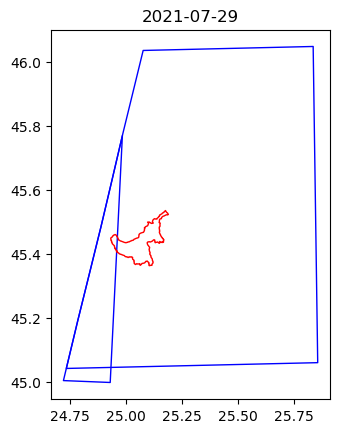

In [26]:
# Visuell überprüfen, ob die AOI effektiv von den selektierten Tiles in der Szene abgedeckt wird
# --> Geometrie des Polygons und der selektierten Tiles plotten 

scene = selected_scenes[0] # hier anpassen, um andere Szene (Datum) anzuschauen

tiles = gpd.GeoDataFrame(
    geometry=[shape(i.geometry) for i in scene["items"]],
    crs="EPSG:4326"
)

aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_geom], crs="EPSG:4326")

ax = tiles.plot(edgecolor="blue", facecolor="none")
aoi_gdf.plot(ax=ax, edgecolor="red", facecolor="none")

plt.title(f"{scene['date']}")
plt.show()

In [27]:
selected_scenes[:2]

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 27),
  'items': [<Item id=S2A_MSIL2A_20210727T092031_R093_T35TLL_20210727T204706>,
   <Item id=S2A_MSIL2A_20210727T092031_R093_T34TGR_20210727T210232>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

### Zusammenfassung & Ergebnis der STAC-Suche

**Kurzbeschrieb, was gemacht wurde:** 

Die Szenenauswahl erfolgte iterativ für jedes Jahr innerhalb eines Hauptloops. Zunächst wurden geeignete Sentinel-2 Tiles über den STAC-Katalog abgefragt (`search_items`). Anschliessend wurden die gefundenen Tiles nach ihrem Aufnahmedatum gruppiert (`group_by_date`), sodass alle Tiles, die zur selben Aufnahme gehören, zu einer Szene zusammengefasst wurden.

In einem nächsten Schritt wurden die Szenen gefiltert. Dazu gehörte die Entfernung geometrischer Duplikaten innerhalb einer Datumsgruppe (`remove_duplicates`) und die Berechnung der räumlichen Abdeckung der AOI durch die zusammengehörigen Tiles (`calculate_coverage`). Es wurden nur Szenen berücksichtigt, die eine nahezu vollständige Abdeckung der AOI (≥ 99 %) aufweisen.

Die verbleibenden validen Szenen wurden anschliessend in der Liste `selected_scenes` gespeichert.


**Ergebnis:**

Die Liste `selected_scenes` enthält die final ausgewählten Szenen (`valid_scenes`) über alle betrachteten Jahre hinweg. Jede Szene wird durch folgende Parameter beschrieben:

- year --> Jahr der Aufnahme
- date --> Aufnahmedatum der Szene
- items --> Liste der zugehörigen STAC-Items (Tiles), die gemeinsam die Szene bilden
- coverage --> Anteil der AOI, der durch die Szene abgedeckt wird (0–1)
- n_tiles --> Anzahl der Tiles, aus denen die Szene besteht

Die enthaltenen STAC-Items umfassen sowohl Metadaten (z.B. Aufnahmezeitpunkt, Wolkenbedeckung und Geometrie) als auch Referenzen (Assets) zu den entsprechenden Rasterdaten.

Die eigentlichen Bilddaten wurden jedoch noch nicht geladen. Um diese für die Analyse zu nutzen, müssen die referenzierten Rasterdaten aus der Cloud abgerufen und verarbeitet werden.

`stackstac` ist ein Tool, das Satellitendaten aus STAC-Katalogen in ein analysierbares, multidimensionales Python-Datenformat (`xarray` + `dask`) verwandelt (siehe auch [stackstac](https://stackstac.readthedocs.io/en/latest/))

## Wolkenärmste Szene pro Jahr bestimmen

Derzeit liegen in `selected_scenes` mehrere Kandidaten (mögliche Szenen --> `valid_scenes`) vor. Davon möchte ich nun pro Untersuchungszeitraum (Jahr) die eine wolkenärmste Szene auswählen. Jedoch nicht die global wolkenärmste, sondern diejenige, welche den geringsten Wolkenanteil über meiner AOI hat (weil z.B.: wenige Wolken global, aber alle über meiner AOI vs. hoher Wolkenanteil aber ausserhalb meiner AOI). 

Über den SCL-Layer lässt sich der Wolkenanteil über meiner AOI bestimmen, indem ich ihn stacke, ein Mosaik bilde (aus mehreren Tiles eine Szene bauen), auf die AOI clippe und im Anschluss die Wolkenpixel zähle. Anhand dieser Information kann ich die Szene auswählen mit den geringsten Wolkenpixel und nur diese Szene für meine Analyse behalten.

**Teslauf mit nur einem Jahr**: Ich bearbeite zuerst nur ein Jahr (anstatt alle Jahre in einem Loop). Weil: Debugging sonst sehr schwierig. Anschliessend Schlaufe über alle Jahre machen, wenn alles funktioniert hat.

### Polygon in gewünschtes CRS bringen

In [28]:
# für spätere Rasteranalyse in metrischem Koordinatensystem arbeiten 
# --> Polygon in neues Koordinatensystem bringen
# --> für die AOI passendes EPSG automatisch bestimmen lassen

aoi_utm = aoi.to_crs(aoi.estimate_utm_crs())               # bestimmt das passende EPSG
print(aoi_utm.crs)     

epsg = int(aoi_utm.crs.to_epsg())                          # nimmt das EPSG als string
print(epsg)
print(type(epsg))

bounds = aoi_utm.geometry.iloc[0].bounds                   # nimmt die bounds des Polygons (später zum Raster laden)

EPSG:32635
32635
<class 'int'>


### Testjahr & Testszene definieren

In [29]:
year_test = 2021
scenes_test = [s for s in selected_scenes if s["year"] == year_test]

In [30]:
len(scenes_test)

12

In [31]:
# Szene zum Testen meiner Funktion

scene = scenes_test[0]

In [32]:
scene

{'year': 2021,
 'date': datetime.date(2021, 7, 29),
 'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
  <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
 'coverage': 0.9999999999999987,
 'n_tiles': 2}

### Funktionen definieren

#### 1. Stack der SCL-Layer erstellen

Mit der Funktion `load_scl_stack` werden die Scene Classification Layer (SCL) der ausgewählten Sentinel-2 Items geladen und zu einem mehrdimensionalen Datenstapel verarbeitet.

Dabei werden nur die SCL-Bänder aus den jeweiligen STAC-Items extrahiert (`assets=["SCL"]`). Die räumliche Auflösung wird auf 20 m gesetzt, entsprechend der nativen Auflösung des SCL-Bands. 

Über die Parameter `bounds` und `epsg` wird der räumliche Ausschnitt sowie das Zielkoordinatensystem definiert, sodass die Daten direkt auf die Untersuchungsregion (AOI) zugeschnitten und in ein metrisches Koordinatensystem überführt werden.

Das Resultat ist ein `xarray.DataArray`, welches alle relevanten SCL-Daten der übergebenen Szenen in einer gemeinsamen, analysierbaren Struktur enthält und die Grundlage für die anschliessende Mosaikbildung und Wolkenanalyse bildet.

In [33]:
from rasterio.enums import Resampling

def load_scl_stack(items, bounds, epsg):

    scl_stack = stackstac.stack(
        items,
        assets=["SCL"],
        resolution=20,
        bounds=bounds,
        epsg=epsg
    )

    return scl_stack

In [34]:
# Überprüfen mit einer Szene

stack = load_scl_stack(
    scene["items"],
    bounds,
    epsg
)

print(stack)

<xarray.DataArray 'stackstac-728ffa6821ae1d82a2bc499c40539871' (time: 2,
                                                                band: 1,
                                                                y: 951, x: 1014)> Size: 15MB
dask.array<fetch_raster_window, shape=(2, 1, 951, 1014), dtype=float64, chunksize=(1, 1, 951, 1014), chunktype=numpy.ndarray>
Coordinates: (12/41)
  * time                                     (time) datetime64[ns] 16B 2021-0...
    id                                       (time) <U54 432B 'S2B_MSIL2A_202...
    s2:product_uri                           (time) <U65 520B 'S2B_MSIL2A_202...
    s2:thin_cirrus_percentage                (time) float64 16B 2.141 0.6203
    s2:dark_features_percentage              (time) float64 16B 0.07394 0.01549
    s2:mean_solar_zenith                     (time) float64 16B 30.37 30.68
    ...                                       ...
    s2:processing_baseline                   <U5 20B '03.00'
    sat:relative_orbit     

#### 2. Mosaik bilden aus mehreren Tiles

Mit der stackstac-Funktion `.mosaic()` (siehe [Dokumentation](https://stackstac.readthedocs.io/en/latest/api/main/stackstac.mosaic.html)) wird entlang der Zeitdimension ein Mosaik gebildet, wobei für jedes Pixel in überlappenden Szenen genau ein Wert ausgewählt wird (*"Flatten a dimension of a DataArray by picking the first valid pixel"*). Standardmässig gilt dabei das Prinzip "last valid observation wins", d.h. wenn mehrere Werte für ein Pixel vorhanden sind, wird der zuletzt vorhandene gültige Wert übernommen. Das Resultat ist ein zusammenhängendes Raster, das aus mehreren Sentinel-2 Tiles zu einer Szene zusammengesetzt wird.

Output: `xarray.DataArray`

In [35]:
def build_scl_mosaic(scl_stack):
    
    scl_mosaic = stackstac.mosaic(scl_stack, dim="time")

    return scl_mosaic

In [36]:
# Überprüfen mit einer Szene

mosaic = build_scl_mosaic(stack)

print(mosaic) # Zeitdimension wurde auf 1 reduziert

<xarray.DataArray 'stackstac-728ffa6821ae1d82a2bc499c40539871' (band: 1,
                                                                y: 951, x: 1014)> Size: 8MB
dask.array<mosaic-aggregate, shape=(1, 951, 1014), dtype=float64, chunksize=(1, 951, 1014), chunktype=numpy.ndarray>
Coordinates: (12/19)
  * band                                     (band) <U3 12B 'SCL'
  * y                                        (y) float64 8kB 5.044e+06 ... 5....
  * x                                        (x) float64 8kB 3.383e+05 ... 3....
    s2:degraded_msi_data_percentage          float64 8B 0.0
    instruments                              <U3 12B 'msi'
    s2:saturated_defective_pixel_percentage  float64 8B 0.0
    ...                                       ...
    s2:processing_baseline                   <U5 20B '03.00'
    sat:relative_orbit                       int64 8B 50
    title                                    <U29 116B 'Scene classfication m...
    proj:shape                           

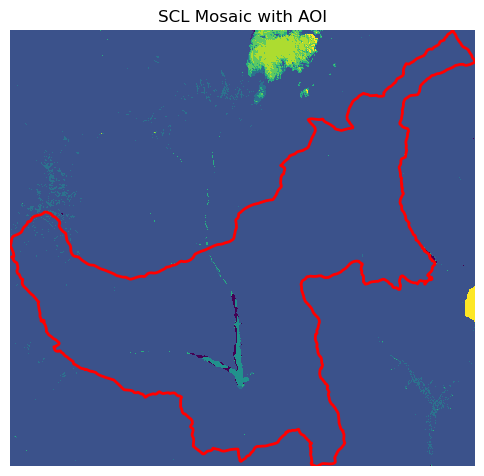

In [37]:
# Überprüfen mittels Plot

import matplotlib.pyplot as plt

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

mosaic.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax = ax, 
    facecolor = "none",
    edgecolor = "red", 
    linewidth = 2
)

plt.title("SCL Mosaic with AOI")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

#### 3. Auf AOI clippen
Da ich den Wolkenanteil nur über meiner AOI berechnen will, clippe ich die SCL-Layer im `scl_stack` auf die AOI. Dazu nutze ich die Funktion `.rio.clip()` von *rioxarray*, und übergebe als Maske meine Polygon-Geometrie und dessen CRS.

In [38]:
def clip_to_aoi(scl_mosaic, aoi_utm):
    
    scl_clipped = scl_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True        
    )

    return scl_clipped

In [39]:
# Clip ausführen
clipped = clip_to_aoi(mosaic, aoi_utm)

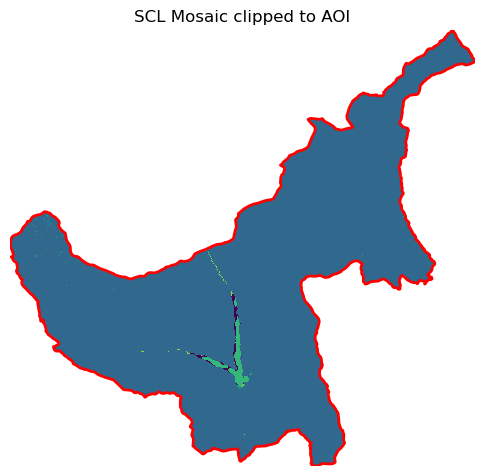

In [40]:
# Überprüfen mittels Plot

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

clipped.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax = ax, 
    facecolor = "none",
    edgecolor = "red", 
    linewidth = 2
)

plt.title("SCL Mosaic clipped to AOI")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

#### 4. Cloud-Maske

Hier definiere ich, welche Pixel als Wolken betrachtet werden. Siehe [Values](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/) in der Sentinelhub Dokumentation.

Ich maskiere folgende Values:
- 3: Cloud Shadows
- 8: Cloud medium probability
- 9: Cloud high probability
- 10: Thin cirrus

Um die Pixelwerte im SCL-Layer zuzuordnen verwende ich die Funktion `.isin()` von *xarray*. Diese prüft für meinen *xarray.DataArray*, ob der Pixelwert im Array den `cloud_classes` entspricht (***True***) oder nicht (***False***). "*Tests each value in the array for whether it is in test elements.*"

In [41]:
def compute_cloud_mask(scl_clipped):
    
    cloud_classes = [3, 8, 9, 10]
    cloud_mask = scl_clipped.isin(cloud_classes) # gibt TRUE zurück, wenn Pixel einer dieser Klassen entspricht
    
    return cloud_mask

In [42]:
clouds = compute_cloud_mask(clipped)

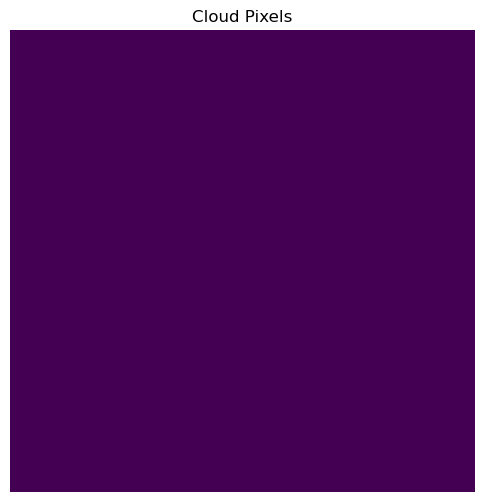

In [43]:
# Überprüfen: nur 0 und 1 Werte

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

clouds.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

plt.title("Cloud Pixels")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

In [44]:
# Raster ist nun rechteckig. Daten jedoch immer noch geclipped?
print(clipped.shape)
print(clouds.shape)

(1, 950, 1013)
(1, 950, 1013)


In [45]:
# Anzahl Wolkenpixel

cloud_pixels = clouds.sum().compute().item()
print(cloud_pixels)

1


In [46]:
# Anzahl Gesamtpixel
total_pixels = clouds.count().compute().item()
print(total_pixels)

962350


#### 5. Cloud-Anteil berechnen

Nun berechne ich den Wolkenanteil über meiner AOI **[0-1]**. Da ich vorher in der Funktion `compute_cloud_mask` alle Pixel in True (ist Wolke) und False (ist nicht Wolke) umgewandelt habe, und Python True == 1 und False == 0 behandelt, kann ich nun den Mittelwert aller Pixel berechnen (= Wolkenanteil [0 - 1]). Je höher der Mittelwert, umso höher der Wolkenanteil. 

Da Stackstac ***lazy*** arbeitet, müssen die Daten mit `.compute()` effektiv geladen werden (sonst ist die Berechnung nur "geplant"). `.item()` wandelt das Ergebnis in einen normalen Python-Wert um (*float* statt *Array*)

In [47]:
def compute_cloud_fraction(cloud_mask):
    cloud_fraction = cloud_mask.mean().compute().item()
    return cloud_fraction

In [48]:
clouds_faction = compute_cloud_fraction(clouds)
clouds_faction

1.0391229802047072e-06

In [49]:
type(clouds_faction)

float

In [50]:
cloud_pixels/total_pixels == clouds_faction

True

### Funktionen verbinden, Loops

#### Pipeline für jede Szene

Nun "klebe" ich meine vorher definierten Funktionen zusammen und baue eine Pipeline zur Verarbeitung einer ***scene*** aus `selected_scenes`.

In [51]:
def process_scene(scene, bounds, epsg, aoi_utm):

    # 1. SCL-Layer laden
    scl_stack = load_scl_stack(scene["items"], bounds, epsg)

    # 2. Mosaik aus mehreren Tiles bauen
    scl = build_scl_mosaic(scl_stack)

    # 3. Auf AOI clippen
    scl = clip_to_aoi(scl, aoi_utm)

    # 4. Wolken maskieren (True / False)
    cloud_mask = compute_cloud_mask(scl)

    # 5. Wolkenanteil berechnen (%)
    cloud_fraction = compute_cloud_fraction(cloud_mask)

    return cloud_fraction

In [52]:
# Überprüfen

process_scene(scene, bounds, epsg, aoi_utm)

1.0391229802047072e-06

In [53]:
# gleiches Resultat wie vorhin? 

process_scene(scene, bounds, epsg, aoi_utm) == clouds_faction

True

#### Loop über ein Jahr (Testlauf)

In [54]:
results = []

for scene in scenes_test:

    cf = process_scene(scene, bounds, epsg, aoi_utm)

    results.append({
    "year": scene["year"],
    "date": scene["date"],
    "cloud_fraction": cf,
    "items": scene["items"],
    "coverage": scene["coverage"],
    "n_tiles": scene["n_tiles"]
    })

In [55]:
len(results)

12

In [56]:
results[ :2]

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 1.0391229802047072e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 27),
  'cloud_fraction': 0.15246428014755548,
  'items': [<Item id=S2A_MSIL2A_20210727T092031_R093_T35TLL_20210727T204706>,
   <Item id=S2A_MSIL2A_20210727T092031_R093_T34TGR_20210727T210232>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

#### Beste Szene des Jahres auswählen (Testlauf):

In [57]:
best_scene = min(results, key=lambda x: x["cloud_fraction"])

best_scene

{'year': 2021,
 'date': datetime.date(2021, 7, 29),
 'cloud_fraction': 1.0391229802047072e-06,
 'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
  <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
 'coverage': 0.9999999999999987,
 'n_tiles': 2}

#### Loop über alle Jahre

In der Liste `selected_scenes` hatte ich alle `valid_scenes` abgespeichert. Nun muss der Loop die ganze Liste, mit allen Jahren, durchlaufen. Als Resultat erhalte ich eine Liste (`results`) mit allen bewerteten Items aus `selected_items` mit Angabe des Wolkenanteils (`cloud_fraction`). Anhand dieses Werts kann ich im Anschluss die Szene mit dem geringsten Wolkenanteil pro Jahr herausfiltern.

In [58]:
results = []

for scene in selected_scenes:

    cf = process_scene(scene, bounds, epsg, aoi_utm)

    results.append({
    "year": scene["year"],
    "date": scene["date"],
    "cloud_fraction": cf,
    "items": scene["items"],
    "coverage": scene["coverage"],
    "n_tiles": scene["n_tiles"]
    })

In [59]:
len(results)

74

In [60]:
results[:5]

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 1.0391229802047072e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 27),
  'cloud_fraction': 0.15246428014755548,
  'items': [<Item id=S2A_MSIL2A_20210727T092031_R093_T35TLL_20210727T204706>,
   <Item id=S2A_MSIL2A_20210727T092031_R093_T34TGR_20210727T210232>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 17),
  'cloud_fraction': 0.12608718241803918,
  'items': [<Item id=S2A_MSIL2A_20210717T092031_R093_T35TLL_20210717T215151>,
   <Item id=S2A_MSIL2A_20210717T092031_R093_T34TGR_20210717T211818>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 14),
  'cloud_fraction': 0.044247934743076846,
  'items': [<Item i

In [61]:
# Überprüfen: entspricht dies meiner Anzahl an Einträgen in selected_scenes?

len(selected_scenes) == len(results)

True

### Beste Szene pro Untersuchungszeitraum auswählen

Jetzt habe ich für alle items in `selected_scenes` einen Wolkenanteil `cloud_fraction` berechnet, wobei die Angaben in der Liste `results` gespeichert sind. Nun muss ich noch die jeweils beste Szene pro Jahr auswählen:

- nach Jahr gruppieren
- beste Szene pro Jahr auswählen

Die besten Szenen pro Jahr speichere ich dann in der Liste `best_scenes`. Mit diesen möchte ich weiterarbeiten.

#### Nach Datum gruppieren

In [62]:
by_year = {}

for r in results:
    year = r["year"]

    if year not in by_year:
        by_year[year] = []

    by_year[year].append(r)

In [63]:
# by_year

#### Beste Szene pro Jahr wählen

Die Werte des Wolkenanteils sind [0 - 1] --> *100 für Angabe in Prozent.

In [64]:
best_scenes = []

for year, items in by_year.items():

    best = min(items, key=lambda x: x["cloud_fraction"])
    best_scenes.append(best)

    print(year, best["date"], best["cloud_fraction"])

2021 2021-07-29 1.0391229802047072e-06
2022 2022-07-22 0.0
2023 2023-07-09 0.0013373512755234583
2024 2024-07-13 0.004652153582376474
2025 2025-07-26 0.0


In [65]:
len(best_scenes)

5

In [66]:
len(best_scenes) == len(years)

True

In [67]:
type(best_scenes)

list

In [68]:
best_scenes

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 1.0391229802047072e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'cloud_fraction': 0.0,
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2023,
  'date': datetime.date(2023, 7, 9),
  'cloud_fraction': 0.0013373512755234583,
  'items': [<Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20241018T102750>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20230709T140728>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20241018T102750>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20230709T140434>],
  'coverage': 0.9999999999999987,
  'n_tile

## Preprocessing

### Rasterdaten aus STAC-Items stacken/laden

**Teslauf mit nur einem Jahr**: Ich bearbeite zuerst nur eine Szene (anstatt alle Szenen in einem Loop). Weil: Debugging sonst sehr schwierig. Anschliessend Schlaufe über alle Szenen machen, wenn alles funktioniert hat.

- Aus ausgewählten Satellitenszenen (aus `best_scenes`) echte Rasterdaten laden
- im metrischen Koordinatensystem (hier EPSG 32635)

siehe auch [STAC + stackstac + xarray](https://hrodmn.dev/posts/stackstac/):

*"When you use stackstac, **you do not need to write any code to handle merging operations for many raster files.** The data come out the other side in a neatly packaged xarray object with x, y, time, and band dimensions! This is very convenient when you are interested in an arbitrary area that may **require combining data from many STAC items**. The [stackstac documentation](https://stackstac.readthedocs.io/en/latest/) is very good, but I have put this demo together to highlight a few things that I really like about the STAC + stackstac + xarray workflow."*

--> "**Lazily load the raster data into an `xarray.DataArray` using `stackstack.stack`**. This function uses the STAC item metadata to construct a multidimensional array with human-readable coordinates that can be manipulated with the magnificently powerful suite of `xarray` functions and methods!"

In [69]:
# Für den "Testlauf" nehme ich das erste Jahr (2021)
scene = best_scenes[0]

In [70]:
scene

{'year': 2021,
 'date': datetime.date(2021, 7, 29),
 'cloud_fraction': 1.0391229802047072e-06,
 'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
  <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
 'coverage': 0.9999999999999987,
 'n_tiles': 2}

Da im Stack-Cube die Auflösung automatisch angepasst wird (resampling) baue ich zwei getrennte Stacks --> einen für die Bänder, mit denen ich arbeiten möchte (Red, NIR etc.) und einen für den SCL-Layer (für Wolkenmaskierung). 

Resampling:
- "bilinear" für kontinuierliche Werte (meine Bänder)
- "nearest" für den SCL-Layer (dieser soll keine Mischung aus Nachbarpixeln machen, da sonst verfälscht)

In [71]:
len(scene["items"]) # --> ich habe 2 items (Tiles) in meiner "Szene"

2

**Funkion `stack_rasters`**: Mit dieser Funktion werden für jede Szene in `best_scenes` zwei DataStacks erstellt:

- einer für die Rasterbänder (R, G, B, NIR etc.) --> `stack_bands`
- einer für den SCL-Layer --> `stack_scl`

In [72]:
import stackstac
from rasterio.enums import Resampling

def stack_rasters(scene, bands, scl, bounds, epsg):

    # STAC-Items aus Dict holen
    items = scene["items"]

    # Spektralbänder stacken
    stack_bands = stackstac.stack(
        items,                              # nimmt das STAC-item
        assets = bands,                     # nimmt die in "Parameter definieren" angegebenen Bänder 
        resolution = 10,                    # definiert die Auflösung --> automatisches resampling!
        resampling = Resampling.bilinear,   # Resampling-Methode --> hier bilienear da kontinuierliche Pixelwerte
        bounds = bounds,                    # nur meinen Ausschnitt laden statt ganze Tiles
        epsg=epsg,                          # des Polygons übernehmen
    )

    # SCL-Layer stacken
    stack_scl = stackstac.stack(
        items,                
        assets = scl,                  
        resolution = 10,                    # definiert die Auflösung --> automatisches resampling!
        resampling = Resampling.nearest,    # Resampling-Methode --> hier nearest (!!) da kategorische Pixelwerte
        bounds = bounds,               
        epsg=epsg,                     
    )

    return stack_bands, stack_scl

In [73]:
# Überprüfen mit Test-Szene:

stack_bands, stack_scl = stack_rasters(
    scene,
    bands,
    scl,
    bounds,
    epsg
)

In [74]:
print(stack_bands)

<xarray.DataArray 'stackstac-a0a2cbc159a834d6855ed340afa18c8b' (time: 2,
                                                                band: 5,
                                                                y: 1901, x: 2027)> Size: 308MB
dask.array<fetch_raster_window, shape=(2, 5, 1901, 2027), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 16B 2021-0...
    id                                       (time) <U54 432B 'S2B_MSIL2A_202...
    s2:product_uri                           (time) <U65 520B 'S2B_MSIL2A_202...
    s2:thin_cirrus_percentage                (time) float64 16B 2.141 0.6203
    s2:dark_features_percentage              (time) float64 16B 0.07394 0.01549
    s2:mean_solar_zenith                     (time) float64 16B 30.37 30.68
    ...                                       ...
    s2:product_type                          <U7 28B 'S2MSI2A'
    s2:datatake_type 

In [75]:
print(type(stack_bands))

<class 'xarray.core.dataarray.DataArray'>


In [76]:
# welche Bänder sind im Stack?
print(stack_bands.band.values)

['B02' 'B03' 'B04' 'B08' 'B12']


### Mosaik erstellen

Das Problem ist nun, dass `stackstack.stack` jedem übergebenen STAC-Item eine eigene Zeitkoordinate zuweist. Ich möchte die Tiles jedoch nicht separat analysieren, sondern daraus ein Mosaik machen, welches ich dann im Stack haben möchte --> **Tiles zu Mosaik zusammenführen, sodass time = 1.**

Dafür verwende ich wiederum die Funktion [stackstac.mosaic()](https://stackstac.readthedocs.io/en/latest/api/main/stackstac.mosaic.html)

In [77]:
def create_mosaic(stack_bands, stack_scl):

    stack_bands_mosaic = stackstac.mosaic(stack_bands, dim="time")
    stack_scl_mosaic = stackstac.mosaic(stack_scl, dim="time")

    return stack_bands_mosaic, stack_scl_mosaic

#### Zwischenergebnis überprüfen

In [78]:
# Überprüfen mit Test-Szene:

stack_bands_mosaic, stack_scl_mosaic = create_mosaic(
    stack_bands,
    stack_scl
)

In [79]:
# Ergebnis betrachten: (--> "time" sollte = 1, resp. nicht in oberster Zeile ausgewiesen sein

print(stack_bands_mosaic)

<xarray.DataArray 'stackstac-a0a2cbc159a834d6855ed340afa18c8b' (band: 5,
                                                                y: 1901, x: 2027)> Size: 154MB
dask.array<mosaic-aggregate, shape=(5, 1901, 2027), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/21)
  * band                                     (band) <U3 60B 'B02' ... 'B12'
    title                                    (band) <U26 520B 'Band 2 - Blue ...
    gsd                                      (band) float64 40B 10.0 ... 20.0
    common_name                              (band) <U6 120B 'blue' ... 'swir22'
    center_wavelength                        (band) float64 40B 0.49 ... 2.19
    full_width_half_max                      (band) float64 40B 0.098 ... 0.242
    ...                                       ...
    s2:product_type                          <U7 28B 'S2MSI2A'
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:datatake_id                       

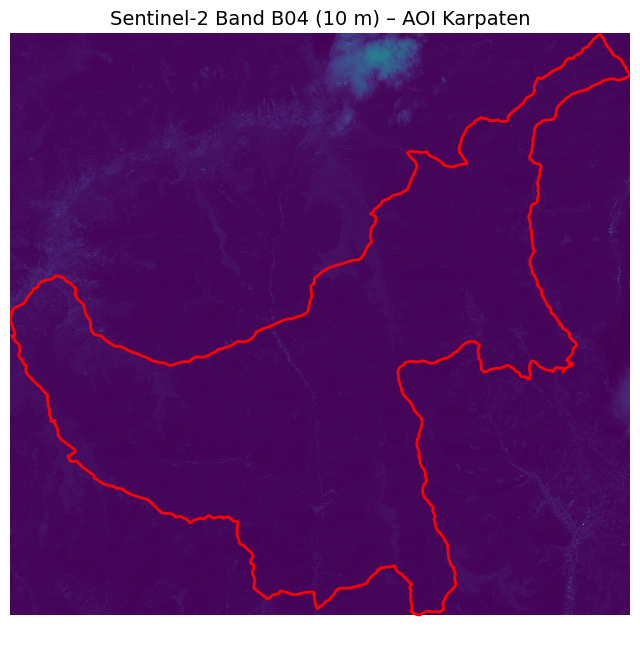

In [80]:
import matplotlib.pyplot as plt

# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# Raster (Sentinel-2 Band B04) plotten
stack_bands_mosaic.sel(band="B04").plot.imshow(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax=ax,
    facecolor="none",     # nur Umrandung, keine Füllung
    edgecolor="red",      # rote Linie
    linewidth=2           # Linienbreite
)

# Titel setzen
ax.set_title("Sentinel-2 Band B04 (10 m) – AOI Karpaten", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

### Auf AOI clippen

In [81]:
def clip_mosaic(stack_bands_mosaic, stack_scl_mosaic, aoi_utm):

    stack_bands_clipped = stack_bands_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True
    )
    
    stack_scl_clipped = stack_scl_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True
    )

    return stack_bands_clipped, stack_scl_clipped

#### Zwischenergebnis überprüfen

In [82]:
# Überprüfen mit Test-Szene:

stack_bands_clipped, stack_scl_clipped = clip_mosaic(
    stack_bands_mosaic,
    stack_scl_mosaic,
    aoi_utm
)

In [83]:
import matplotlib.colors as mcolors

# SCL-Klassen (0–11)
classes = list(range(12))

# Farben (ESA-ähnlich / gut unterscheidbar)
colors = [
    "#000000",  # 0: No data
    "#ff0000",  # 1: Saturated/defective
    "#2f2f2f",  # 2: Dark area / shadows
    "#643200",  # 3: Cloud shadows
    "#00a000",  # 4: Vegetation
    "#ffe65a",  # 5: Not vegetated
    "#0000ff",  # 6: Water
    "#808080",  # 7: Unclassified
    "#c0c0c0",  # 8: Cloud medium prob
    "#ffffff",  # 9: Cloud high prob
    "#64c8ff",  # 10: Thin cirrus
    "#ff96ff",  # 11: Snow/ice
]

# Diskrete Colormap
cmap = mcolors.ListedColormap(colors)

# damit matplotlib die Werte nicht als kontinuierlich behandelt
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(0, 12, 1),
    ncolors=12
)

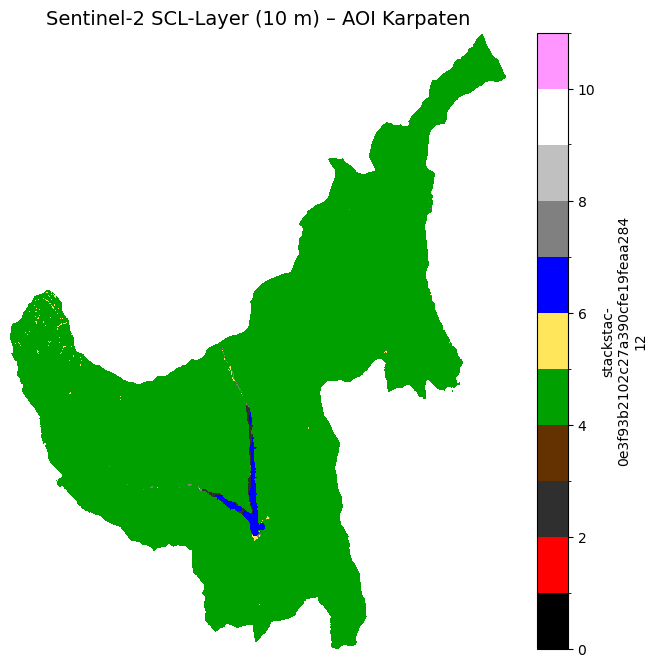

In [84]:
# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# Raster (SCL-Layer) plotten
stack_scl_clipped.sel(band="SCL").plot.imshow(
    ax=ax,
    cmap = cmap,
    norm = norm
)

# Titel setzen
ax.set_title("Sentinel-2 SCL-Layer (10 m) – AOI Karpaten", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

### Wolkenmaskierung

- Maske erstellen (siehe [Values](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/) in der Sentinelhub Dokumentation
- Maske auf die Raster im Stack mit meinem Bändern (`stack_bands`) anwenden

Ich maskiere folgende Values:
- 3: Cloud Shadows
- 8: Cloud medium probability
- 9: Cloud high probability
- 10: Thin cirrus

In [85]:
clouds=[3, 8, 9, 10]

In [86]:
def mask_clouds(stack_bands_clipped, stack_scl_clipped, clouds):

    # SCL-Layer auswählen
    scl_layer = stack_scl_clipped.sel(band="SCL")

    # True = gültiger Pixel, False = Wolke/Schatten
    cloud_mask = ~scl_layer.isin(clouds)

    # True = Wolkenpixel
    cloud_pixels = ~cloud_mask

    # Maske auf alle Bänder anwenden
    stack_bands_masked = stack_bands_clipped.where(cloud_mask)

    return stack_bands_masked, cloud_mask, cloud_pixels

In [87]:
def mask_clouds(stack_bands_clipped, stack_scl_clipped, clouds):

    scl_layer = stack_scl_clipped.sel(band="SCL")

    cloud_mask = ~scl_layer.isin(clouds)   # True = gültig
    cloud_pixels = ~cloud_mask             # True = Wolke

    stack_bands_masked = stack_bands_clipped.where(cloud_mask)

    return stack_bands_masked, cloud_mask, cloud_pixels

#### Zwischenergebnis überprüfen

***--> Anhand des RGB-Composites*** (siehe Kapitel "Composites erstellen --> RGB-Composite zur Kontrolle"

### Loop über alle Szenen / Jahre
Hier verpacke ich die vorher definierten Funktionen `stack_rasters`, `create_mosaic`, `clip_mosaic` und `mask_clouds` in einen Loop über alle Jahre.

Zusätzlich speichere ich die Wolkenmaske als Raster für jedes Jahr, damit ich diese später nutzen kann für die Zeitreihenanalyse. Weil: für eine vollständige Zeitreihe verwende ich nur Pixel, die auf keinem der Raster Wolken hatten (bei dem niedrigen Wolkenanteil vertretbar).

In [88]:
best_scenes[:1]

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 1.0391229802047072e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

In [89]:
processed_scenes = {}

for scene in best_scenes:

    year = scene["year"]
    date = scene["date"]

    print(f"Processing {year} | {date}")

    # 1. Raster stacken
    stack_bands, stack_scl = stack_rasters(
        scene,
        bands,
        scl,
        bounds,
        epsg
    )

    # 2. Mosaik erstellen
    stack_bands_mosaic, stack_scl_mosaic = create_mosaic(
        stack_bands,
        stack_scl
    )

    # 3. Auf AOI clippen
    stack_bands_clipped, stack_scl_clipped = clip_mosaic(
        stack_bands_mosaic,
        stack_scl_mosaic,
        aoi_utm
    )

    # 4. Wolken maskieren
    stack_bands_masked, cloud_mask, cloud_pixels = mask_clouds(
        stack_bands_clipped,
        stack_scl_clipped,
        clouds
    )

    # 5. Wolkenmaske pro Jahr abspeichern (für spätere Verwendung)
    
    # von Boolean in 1/0 umwandeln
    valid_mask = cloud_mask.astype("uint8") # 1 = gültig, 0 = Wolke
    
    # CRS sicherstellen
    valid_mask = valid_mask.rio.write_crs(f"EPSG:{epsg}")

    # Wolken-Raster speichern (im Ordner Composites_GeoTIFF)
    valid_mask.rio.to_raster(f"Composites_GeoTIFF/ValidMask_{year}.tif")
    print(f"Saved ValidMask_{year} as GeoTIFF")

    # 6. Ergebnisse speichern
    processed_scenes[year] = {
        "date": date,
        "stack_bands": stack_bands_clipped,
        "stack_scl": stack_scl_clipped,
        "stack_bands_masked": stack_bands_masked,
        "cloud_mask": cloud_mask,
        "cloud_pixels": cloud_pixels,
        "cloud_fraction": scene["cloud_fraction"],
        "n_tiles": scene["n_tiles"]
    }

    print(f"Done {year}")

Processing 2021 | 2021-07-29
Saved ValidMask_2021 as GeoTIFF
Done 2021
Processing 2022 | 2022-07-22
Saved ValidMask_2022 as GeoTIFF
Done 2022
Processing 2023 | 2023-07-09
Saved ValidMask_2023 as GeoTIFF
Done 2023
Processing 2024 | 2024-07-13
Saved ValidMask_2024 as GeoTIFF
Done 2024
Processing 2025 | 2025-07-26
Saved ValidMask_2025 as GeoTIFF
Done 2025


In [90]:
len(processed_scenes)

5

In [91]:
print(processed_scenes[2021]["stack_bands_masked"])

<xarray.DataArray 'stackstac-a0a2cbc159a834d6855ed340afa18c8b' (band: 5,
                                                                y: 1900, x: 2026)> Size: 154MB
dask.array<where, shape=(5, 1900, 2026), dtype=float64, chunksize=(1, 1023, 1023), chunktype=numpy.ndarray>
Coordinates: (12/21)
  * band                                     (band) <U3 60B 'B02' ... 'B12'
    common_name                              (band) <U6 120B 'blue' ... 'swir22'
    center_wavelength                        (band) float64 40B 0.49 ... 2.19
    full_width_half_max                      (band) float64 40B 0.098 ... 0.242
  * y                                        (y) float64 15kB 5.044e+06 ... 5...
  * x                                        (x) float64 16kB 3.383e+05 ... 3...
    ...                                       ...
    s2:datatake_id                           <U34 136B 'GS2B_20210729T090559_...
    s2:processing_baseline                   <U5 20B '03.00'
    sat:relative_orbit            

## Composites erstellen

Achtung: Composites der Indices mit `stack_bands_masked` erstellen!!

- $NDVI: (NIR - Red) / (NIR + Red)$ --> `(B08 - B04) / (B08 + B04)`
- $NBR: (NIR - SWIR) / (NIR + SWIR)$ --> `(B08 - B12) / (B08 + B12)`

**Wieder zuerst für ein Testjahr, dann Loop über alle Jahre.**

Um die Outputs zu speichern lege ich hier Ordner an, in welche die Plots / Composites später gespeichert werden.

In [92]:
import os

os.makedirs("Composites_GeoTIFF", exist_ok=True)
os.makedirs("Composites_Plots", exist_ok=True)

### RGB-Composite zur Kontrolle

Für den späteren Vergleich und Kontrolle erstelle ich ein RGB-Composite. siehe auch dieses [Script](https://www.satmapper.hu/en/rgb-images/)

stackstac arbeitet *lazy* "was ich berechnen würde" --> `.compute()` lädt die Daten in meinen Speicher

- erst mit einem Testjahr
- dann Loop über alle `stack_bands` in `processed_scenes`

In [93]:
year = 2021

print(processed_scenes[year]["date"])

2021-07-29


In [94]:
print(processed_scenes[year].keys())

dict_keys(['date', 'stack_bands', 'stack_scl', 'stack_bands_masked', 'cloud_mask', 'cloud_pixels', 'cloud_fraction', 'n_tiles'])


In [95]:
test_bands = processed_scenes[year]["stack_bands"]

In [96]:
# RGB-Bänder extrahieren
red = test_bands.sel(band="B04").compute()
green = test_bands.sel(band="B03").compute()
blue = test_bands.sel(band="B02").compute()

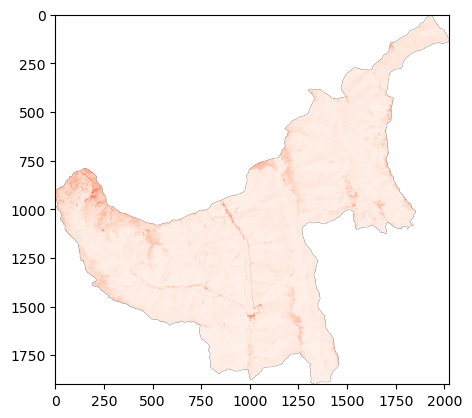

In [97]:
plt.imshow(red, cmap='Reds')

In [98]:
red.shape
# red ist ein 2D-Array 

(1900, 2026)

In [99]:
# Werte normalisieren auf 0-1
def normalize(band):
    band_min, band_max = (band.min(), band.max())
    return ((band-band_min)/((band_max - band_min)))

red_n = normalize(red)
green_n = normalize(green)
blue_n = normalize(blue)

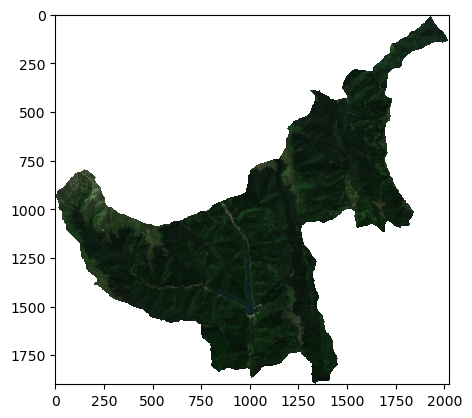

In [100]:
rgb_composite_n= np.dstack((red_n, green_n, blue_n))
plt.imshow(rgb_composite_n)

Bild ist sehr dunkel --> um die Farben zu "verbessern" helle ich diese auf (Bildmanipulation).

In [101]:
def brighten(band):
    alpha=0.13
    beta=0
    return np.clip(alpha*band+beta, 0,255)

red_b=brighten(red)
blue_b=brighten(blue)
green_b=brighten(green)

red_bn = normalize(red_b)
green_bn = normalize(green_b)
blue_bn = normalize(blue_b)

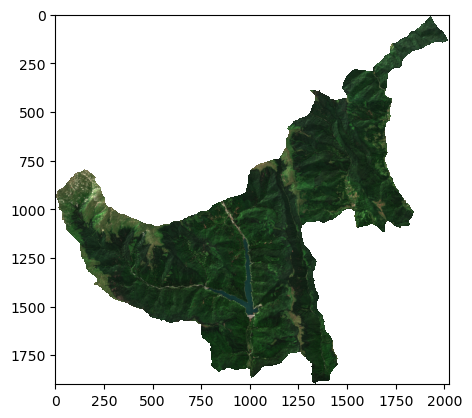

In [102]:
rgb_composite_bn= np.dstack((red_bn, green_bn, blue_bn))
plt.imshow(rgb_composite_bn)

In [103]:
# Als PNG peichern
rgb_plot=plt.imshow(rgb_composite_bn, interpolation='lanczos')
plt.axis('off')
plt.title(f"RGB Image | {year} | {processed_scenes[year]['date']}", fontsize=14)
plt.savefig("RGB_Test.png",dpi=900,bbox_inches='tight')
plt.close('all')

#### Loop über alle Jahre

In [104]:
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    return (band - band_min) / (band_max - band_min)

def brighten(band, alpha=0.13, beta=0):
    return np.clip(alpha * band + beta, 0, 255)

for year, data in processed_scenes.items():

    print(f"Processing RGB {year}")

    stack = data["stack_bands"]

    # -----------------------------
    # 1. RGB als GeoTIFF speichern (roh)
    # -----------------------------
    
    rgb_xr = stack.sel(band=["B04", "B03", "B02"])
    rgb_xr = rgb_xr.rio.write_crs(f"EPSG:{epsg}")

    rgb_xr.rio.to_raster(f"Composites_GeoTIFF/RGB_{year}.tif")
    print(f"Saved RGB_{year} as GeoTIFF")

    # -----------------------------
    # 2. RGB für Plot erzeugen
    # -----------------------------
    
    red = stack.sel(band="B04").compute()
    green = stack.sel(band="B03").compute()
    blue = stack.sel(band="B02").compute()

    # Aufhellen
    red_b = brighten(red)
    green_b = brighten(green)
    blue_b = brighten(blue)

    # Normalisieren
    red_n = normalize(red_b)
    green_n = normalize(green_b)
    blue_n = normalize(blue_b)

    # RGB zusammensetzen (NumPy)
    rgb = np.dstack((red_n, green_n, blue_n))

    # Optional speichern im Dict
    processed_scenes[year]["rgb"] = rgb

    # -----------------------------
    # 3. Plot speichern
    # -----------------------------
    
    plt.figure(figsize=(8, 8))
    plt.imshow(rgb, interpolation="lanczos")
    plt.axis("off")
    plt.title(f"RGB Image | {year} | {data['date']}")

    plt.savefig(f"Composites_Plots/RGB_{year}.png", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved RGB_{year} as PNG")
    print("-" * 35)

Processing RGB 2021
Saved RGB_2021 as GeoTIFF
Saved RGB_2021 as PNG
-----------------------------------
Processing RGB 2022
Saved RGB_2022 as GeoTIFF
Saved RGB_2022 as PNG
-----------------------------------
Processing RGB 2023
Saved RGB_2023 as GeoTIFF
Saved RGB_2023 as PNG
-----------------------------------
Processing RGB 2024
Saved RGB_2024 as GeoTIFF
Saved RGB_2024 as PNG
-----------------------------------
Processing RGB 2025
Saved RGB_2025 as GeoTIFF
Saved RGB_2025 as PNG
-----------------------------------


#### Wolkenmaskierung überprüfen (visuell)

Der Output der Funktion ***mask_clouds*** ist:

- `stack_bands_masked` --> Von Wolken bereinigte Spektralraster
- `cloud_mask` --> Wolkenmaske (gültiger Pixel = True, Wolkenpixel = False)
- `cloud_pixels` --> invertierte Wolkenmaske --> Wolkenpixel = True

Den Output `cloud_pixels` kann ich also direkt verwenden, um Wolkenpixel über das RGB-Composite zu legen.

**Hier manuell arbeiten -> Jahr im RGB-Bild anpassen**. Visuell überprüfen, ob die Wolkenmaskierung Sinn macht.

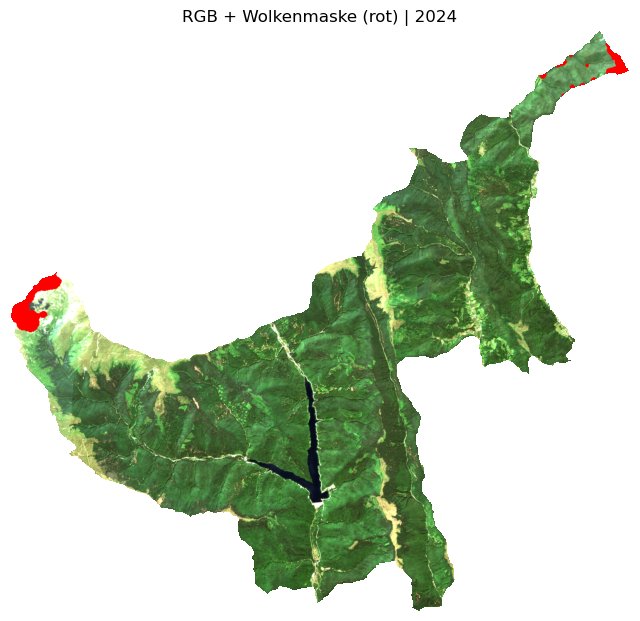

In [105]:
year = 2024

rgb = processed_scenes[year]["rgb"]
cloud_pixels = processed_scenes[year]["cloud_pixels"].compute().values

rgb_check = rgb.copy()
rgb_check[cloud_pixels] = [1, 0, 0] 

plt.figure(figsize=(8, 8))
plt.imshow(rgb_check)
plt.axis("off")
plt.title(f"RGB + Wolkenmaske (rot) | {year}")
plt.show()

### NDVI-Composite erstellen

In [106]:
year = 2021

print(processed_scenes[year]["date"])

2021-07-29


In [107]:
print(processed_scenes[year].keys())

dict_keys(['date', 'stack_bands', 'stack_scl', 'stack_bands_masked', 'cloud_mask', 'cloud_pixels', 'cloud_fraction', 'n_tiles', 'rgb'])


In [108]:
test_bands = processed_scenes[year]["stack_bands_masked"]

In [109]:
red = test_bands.sel(band="B04").compute()
nir = test_bands.sel(band="B08").compute()

# NDVI berechnen mit Schutz vor Division durch 0 --> wenn NIR + RED = 0, dann Pixel = nan
# "wenn nir + red nicht null sind, dann (nir - red) / (nir + red), sonst nan"
ndvi = xr.where((nir + red) != 0, (nir - red) / (nir + red), np.nan)

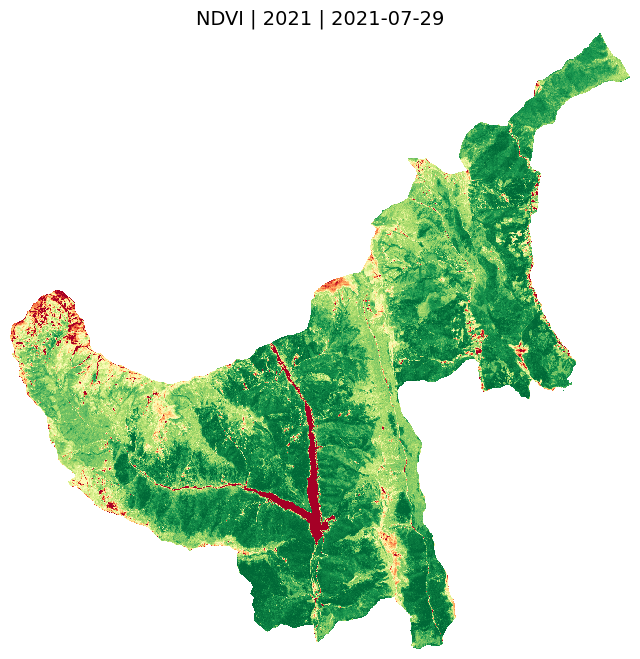

In [110]:
# Farbskala definieren
color_scale = "RdYlGn"

# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# NDVI plotten mit Rot --> Grün Farbskala & Penzentil-Stretch (für besseren Kontrast)
ndvi.plot.imshow(
    ax=ax,
    cmap = color_scale,                      # Farbskala
    add_colorbar=False,                      # keine Farblegende
    vmin=np.nanpercentile(ndvi, 2),          # setzt unteren Farbwert: der Wert, unter dem (hier) 2% der Daten liegen
    vmax=np.nanpercentile(ndvi, 98)          # setzt oberen Farbwert: der Wert, unter dem (hier) 98% der Daten liegen
)

# Titel setzen
ax.set_title(f"NDVI | {year} | {processed_scenes[year]['date']}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot direkt als PNG speichern
plt.savefig("NDVI_Test.png", dpi=900, bbox_inches="tight") 

# Plot anzeigen
plt.show()

#### Loop über alle Jahre

- Einerseits Loop zur Berechnung der NDVI-Raster und zur Erstellung und Speicherung der Plots
- Andererseits hier direkt die NDVI-Raster in korrektes CRS bringen (sicherstellen) und als GeoTIFF abspeichern, um in einem anderen Skript damit weiterarbeiten zu können.

In [111]:
for year, data in processed_scenes.items():

    print(f"Processing NDVI {year}")

    stack = data["stack_bands_masked"]

    # Bänder auswählen
    red = stack.sel(band="B04").compute()
    nir = stack.sel(band="B08").compute()

    # NDVI berechnen
    ndvi = xr.where((nir + red) != 0, (nir - red) / (nir + red), np.nan)

    # NDVI in processed_scenes speichern
    processed_scenes[year]["ndvi"] = ndvi

    # CRS sicherstellen
    ndvi = ndvi.rio.write_crs(f"EPSG:{epsg}")

    # NDVI-Raster speichern (im Ordner Composites_GeoTIFF)
    ndvi.rio.to_raster(f"Composites_GeoTIFF/NDVI_{year}.tif")
    print(f"Saved NDVI_{year} as GeoTIFF")

    # Percentile berechnen
    vmin = np.nanpercentile(ndvi, 2)
    vmax = np.nanpercentile(ndvi, 98)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    ndvi.plot.imshow(
        ax=ax,
        cmap="RdYlGn",
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"NDVI | {year} | {data['date']}", fontsize=14)
    ax.set_axis_off()

    # Speichern
    plt.savefig(f"Composites_Plots/NDVI_{year}.png", dpi=300, bbox_inches="tight")

    plt.close()

    print(f"Saved NDVI_{year} as PNG")
    print("-" * 35) # als Abgrenzung zur nächsten Iteration

Processing NDVI 2021
Saved NDVI_2021 as GeoTIFF
Saved NDVI_2021 as PNG
-----------------------------------
Processing NDVI 2022
Saved NDVI_2022 as GeoTIFF
Saved NDVI_2022 as PNG
-----------------------------------
Processing NDVI 2023
Saved NDVI_2023 as GeoTIFF
Saved NDVI_2023 as PNG
-----------------------------------
Processing NDVI 2024
Saved NDVI_2024 as GeoTIFF
Saved NDVI_2024 as PNG
-----------------------------------
Processing NDVI 2025
Saved NDVI_2025 as GeoTIFF
Saved NDVI_2025 as PNG
-----------------------------------


### NBR-Composite erstellen

In [112]:
year = 2021

print(processed_scenes[year]["date"])

2021-07-29


In [113]:
test_bands = processed_scenes[2021]["stack_bands_masked"]

In [114]:
nir = test_bands.sel(band="B08").compute()
swir = test_bands.sel(band="B12").compute()

# NBR berechnen mit Schutz vor Division durch 0 --> wenn NIR + SWIR = 0, dann Pixel = nan
# "wenn nir + swir nicht null sind, dann (nir - swir) / (nir + swir), sonst nan"
nbr = xr.where((nir + swir) != 0, (nir - swir) / (nir + swir), np.nan)

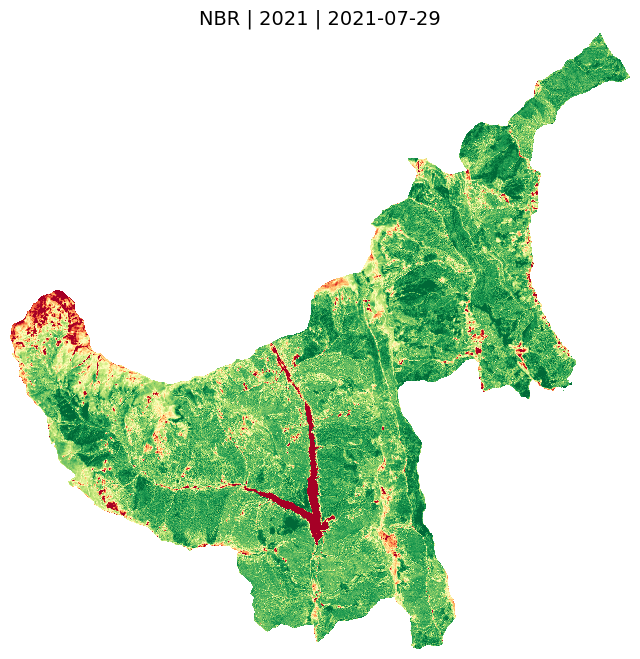

In [115]:
# Farbskala definieren
color_scale = "RdYlGn"

# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# NBR plotten mit Rot --> Grün Farbskala & Penzentil-Stretch (für besseren Kontrast)
nbr.plot.imshow(
    ax=ax,
    cmap = color_scale,                     # Farbskala
    add_colorbar=False,                     # keine Farblegende
    vmin=np.nanpercentile(nbr, 2),          # setzt unteren Farbwert: der Wert, unter dem (hier) 2% der Daten liegen
    vmax=np.nanpercentile(nbr, 98)          # setzt oberen Farbwert: der Wert, unter dem (hier) 98% der Daten liegen
)

# Titel setzen
ax.set_title(f"NBR | {year} | {processed_scenes[year]['date']}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot direkt als PNG speichern
plt.savefig("NBR_Test.png", dpi=900, bbox_inches="tight") 

# Plot anzeigen
plt.show()

#### Loop über alle Jahre

In [116]:
for year, data in processed_scenes.items():

    print(f"Processing NBR {year}")

    stack = data["stack_bands_masked"]

    # Bänder auswählen
    nir = stack.sel(band="B08").compute()
    swir = stack.sel(band="B12").compute()

    # NBR berechnen
    nbr = (nir - swir) / (nir + swir)

    # NBR in processed_scenes speichern
    processed_scenes[year]["nbr"] = nbr

    # CRS sicherstellen
    nbr = nbr.rio.write_crs(f"EPSG:{epsg}")

    # NBR-Raster speichern (im Ordner Composites_GeoTIFF)
    nbr.rio.to_raster(f"Composites_GeoTIFF/NBR_{year}.tif")
    print(f"Saved NBR{year} as GeoTIFF")

    # Percentile berechnen
    vmin = np.nanpercentile(nbr, 2)
    vmax = np.nanpercentile(nbr, 98)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    nbr.plot.imshow(
        ax=ax,
        cmap="RdYlGn",
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"NBR | {year} | {data['date']}", fontsize=14)
    ax.set_axis_off()

    # Speichern
    plt.savefig(f"Composites_Plots/NBR_{year}.png", dpi=300, bbox_inches="tight")

    plt.close()

    print(f"Saved NBR_{year} as PNG")
    print("-" * 35) # als Abgrenzung zur nächsten Iteration

Processing NBR 2021
Saved NBR2021 as GeoTIFF
Saved NBR_2021 as PNG
-----------------------------------
Processing NBR 2022
Saved NBR2022 as GeoTIFF
Saved NBR_2022 as PNG
-----------------------------------
Processing NBR 2023
Saved NBR2023 as GeoTIFF
Saved NBR_2023 as PNG
-----------------------------------
Processing NBR 2024
Saved NBR2024 as GeoTIFF
Saved NBR_2024 as PNG
-----------------------------------
Processing NBR 2025
Saved NBR2025 as GeoTIFF
Saved NBR_2025 as PNG
-----------------------------------
